In [2]:

import torch 
from torch import nn, Tensor 
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from typing import override 
import matplotlib.pyplot as plt 
from enum import Enum
import numpy as np 
import re 

import ipywidgets as widgets
from IPython.display import display
from pprint import pprint

class Mode(Enum):
    CNN = 1
    BasicTransformer = 2

    def to_string(self):
        return self.name

MODE = Mode.BasicTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"


# ================================================================
# Version 1: CNN Architecture
# ================================================================
class FlowMatching(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.digit_embedding = nn.Embedding(10, 64)
        self.time_embedding = nn.Sequential(
            nn.Linear(1, 64),
            nn.SiLU(),
            nn.Linear(64, 64)
        )
        self.net = nn.Sequential(
            nn.Conv2d(1 + 64 + 64, 64, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(64, 1, 3, padding=1),
        )



    @override 
    def forward(self, x, t, digit):

        B, _, H, W = x.shape 
        
        digit_emb = self.digit_embedding(digit)

        # Embed digit: [B, 64] -> [B, 64, H, W]
        digit_emb = digit_emb[:, :, None, None]
        digit_emb = digit_emb.expand(-1, -1, H, W)

        # Embed time: [B] -> [B, 1] -> [B, 64]
        time_emb = self.time_embedding(t[:, None])

        # [B, 64] -> [B, 64, H, W]
        time_emb = time_emb[:, :, None, None].expand(-1, -1, H, W)

        # concatenate everything 
        x = torch.cat([x, digit_emb, time_emb], dim=1)

        return self.net(x)


# ================================================================
# version 2: transformer architecture
# ================================================================
class FlowMatching_with_Transformer(nn.Module):
    def __init__(self):
        super().__init__() 

        self.embedding_dim=64

        self.digit_embedding = nn.Embedding(
            num_embeddings=10,
            embedding_dim=self.embedding_dim
        )

        self.time_embedding = nn.Sequential(
            nn.Linear(1, self.embedding_dim),
            nn.SiLU(),
            nn.Linear(self.embedding_dim, self.embedding_dim),
        )

        self.patch_embedding = nn.Conv2d(
            in_channels=1,
            out_channels=self.embedding_dim,
            kernel_size=4,
            stride=4,
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, 49, self.embedding_dim)
        )

        self.num_layers = 8
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=self.embedding_dim,
                nhead=4,
                dim_feedforward=128,
                batch_first=True,
                dropout=0.0 
            )
            for _ in range(self.num_layers)
        ])

        self.output_proj = nn.Sequential(
            nn.Linear(self.embedding_dim, self.embedding_dim),
            nn.SiLU(),
            nn.Linear(self.embedding_dim, 16),
        )

    @override
    def forward(self, x, t, digit):

        digit_emb = self.digit_embedding(digit)
        digit_emb = digit_emb.unsqueeze(1)

        time_emb = self.time_embedding(t.unsqueeze(1)).unsqueeze(1)

        patch = self.patch_embedding(x)
        patch = patch.flatten(2)
        patch = patch.transpose(1, 2)

        image_tokens = patch + self.pos_embedding

        x = torch.cat([
            digit_emb, 
            time_emb,
            image_tokens,
            ], dim=1
        )

        for layer in self.layers:
            x = layer(x)


        # remove digit and time tokens again 
        image_tokens = x[:, 2:, :]

        # convert each token back into a 4x4 patch 
        patches = self.output_proj(image_tokens)
        patches = patches.transpose(1, 2) # back to [B, 16, 49]

        # reconstruct the velocity image 
        velocity = F.fold(
            patches, 
            output_size=(28, 28),
            kernel_size=4,
            stride=4,
        ) # [B, 1, 28, 28]

        return velocity

# ================================================================
# Training
# ================================================================

def create_loader(training_size=1024, batch_size=128) -> DataLoader:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = datasets.MNIST(
        root="./data", 
        train=True,
        download=True,
        transform=transform,
    )

    indices = torch.randperm(len(dataset))[:training_size]
    dataset = Subset(dataset, indices)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
    )


def train(model, loader, training_epochs=20):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    for epoch in range(training_epochs):

        total_loss = 0 

        for x1, digit in loader:

            x1 = x1.to(device)
            digit = digit.to(device)

            B = x1.shape[0]
            x0 = torch.randn_like(x1) # gausssian source distribution

            t = torch.rand(B, device=device)

            t_img = t[:, None, None, None]
            xt = ((1 - t_img) * x0 + t_img * x1)

            target_velocity = x1 - x0
            predicted_velocity = model(xt, t, digit)

            loss = F.mse_loss(
                predicted_velocity,
                target_velocity,
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step() 

            total_loss += loss.item() 

        print(
            f"Epoch {epoch + 1}: "
            f"loss = {total_loss / len(loader):.4f}"
        )

@torch.no_grad()
def generate(model, digits, steps):

    model.eval() 

    B = len(digits)
    x = torch.randn(
        B, 1, 28, 28,
        device=device,
    )

    dt = 1.0 / steps

    for i in range(steps):
        t = torch.full(
            (B,),
            i / steps,
            device=device
        ) # Creates tensor of batch_size with the current time step

        velocity = model(
            x,
            t,
            digits,
        )

        x += dt * velocity

    return x 

def show_all_digits(model, denoising_steps=50):
    digits = torch.arange(10, device=device)
    samples = generate(
        model, digits, steps=denoising_steps
    )

    fig, axes = plt.subplots(1, 10, figsize=(15, 2))

    for i, ax in enumerate(axes):
        ax.imshow(
            samples[i, 0].cpu(),
            cmap="gray",
        )

        ax.set_title(str(i))
        ax.axis("off")
    plt.show()

def save_model(model, name_suffix="") -> None:
    filename = f"{MODE.to_string()}_{name_suffix}.pt"
    model.to("cpu")
    model.eval()
    torch.save(model.state_dict(), filename)

def load_model(model, name_suffix="") -> nn.Module:
    filename = f"{MODE.to_string()}_{name_suffix}.pt"
    model.load_state_dict(torch.load(filename, map_location=device))
    return model.to(device)

def visualize_params(state_dict, initial_state_dict=None):
    """
    Interactive visualization of parameter statistics across Transformer layers.

    Parameters 
    ---------- 
    model: 
        Traned/current PyTorch model. 

    initial_state_dict: 
        State dict of the model before training.
        If provided, additional metrics such as relative parameter change become 
        available. 

    Example usage before training: 

    inital_state = {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }
    """

    layer_params = {}

    pattern = re.compile(
        r"^layers\.(\d+)\.(.+)$"
    )

    for name, tensor in state_dict:

        match = pattern.match(name)

        if match is None:
            continue

        layer_idx = int(match.group(1))
        param_name = match.group(2)

        # Only parameters, not buffers
        if not torch.is_tensor(tensor):
            continue

        layer_params.setdefault(layer_idx, {})
        layer_params[layer_idx][param_name] = tensor.detach().cpu().float()

    if not layer_params: 
        raise ValueError(
            "Could not automatically find Transformer layers. "
            "Check model.named_parameters()."
        )

    def categorize(name):
        if "self_attn.in_proj" in name:
            return "Attention QKV"
        if "self_attn.out_proj" in name: 
            return "Attention Output"
        if "linear1" in name: 
            return "FFN Input"
        if "linear2" in name: 
            return "FFN Output"
        if "norm1" in name: 
            return "LayerNorm 1"
        if "norm2" in name: 
            return "LayerNorm 2"
    
        return "Other"

    categories = [
        "Attention QKV",
        "Attention Output",
        "FFN Input", 
        "FFN Output",
        "LayerNorm 1",
        "LayerNorm 2",
        "Other",
    ]
    category_selector = widgets.SelectMultiple(
        options=categories,
        value=tuple(categories[:4]),
        description="Params:",
        layout=widgets.Layout(
            width="300px",
            height="150px"
        ),
    )

    metric_options = [
        "L2 norm",
        "Mean absolute value",
        "Standard deviation",
        "Relative change",
        "Absolute change",
    ]

    if initial_state_dict is None:
        metric_options = metric_options[:3]

    metric_selector = widgets.Dropdown(
        options=metric_options,
        value=metric_options[0],
        description="Metric:",
        layout=widgets.Layout(width="300px"),
    )

    log_scale = widgets.Checkbox(
        value=False,
        description="Log scale"

    )

    output = widgets.Output()

    # Calculate metrics 

    def calculate_metric(full_name, tensor, metric):

        tensor = tensor.detach().cpu().float()

        if metric == "L2 norm":
            return float(torch.linalg.vector_norm(tensor))
        elif metric == "Mean absolute value":
            return float(tensor.abs().mean())
        elif metric == "Standard deviation":
            return float(tensor.std())

        # Metrics below require initial_state_dict
        if initial_state_dict is None:
            return np.nan
        if full_name not in initial_state_dict:
            return np.nan

        initial = (
            initial_state_dict[full_name]
            .detach()
            .cpu()
            .float()
        )

        difference = tensor - initial

        if metric == "Absolute change":
            return float(
                torch.linalg.vector_norm(difference)
            )

        elif metric == "Relative change":

            epsilon = 1e-8

            return float(
                torch.linalg.vector_norm(difference)
                /
                (
                    torch.linalg.vector_norm(initial)
                    + epsilon
                )
            )
        return np.nan

    def update(*args):

        with output:
            output.clear_output(wait=True)

            selected = category_selector.value
            metric = metric_selector.value

            if not selected:
                print("Select at least one parameter group.")
                return

            matrix = []
            row_labels = []

            layer_indices = sorted(layer_params.keys())

            for selected_category in selected:
                values = []

                for layer_idx in layer_indices:

                    category_values = []

                    for param_name, tensor in layer_params[layer_idx].items():

                        # Check whether this parameter belongs
                        # to the selected category
                        if categorize(param_name) != selected_category:
                            continue

                        full_name = (
                            f"layers.{layer_idx}.{param_name}"
                        )

                        value = calculate_metric(
                            full_name,
                            tensor,
                            metric,
                        )

                        # Only add valid values
                        if value is not None and np.isfinite(value):
                            category_values.append(float(value))

                    # --------------------------------------------
                    # Important: handle missing parameters
                    # --------------------------------------------

                    if category_values:
                        values.append(
                            float(np.mean(category_values))
                        )
                    else:
                        values.append(np.nan)

                matrix.append(values)
                row_labels.append(selected_category)

            matrix = np.asarray(matrix, dtype=float)

            # --------------------------------------------
            # Plot
            # --------------------------------------------

            plot_matrix = matrix.copy()

            if log_scale.value:
                plot_matrix = np.log10(
                    np.maximum(
                        np.abs(plot_matrix),
                        1e-12,
                    )
                )

            fig, ax = plt.subplots(
                figsize=(
                    max(8, len(layer_indices) * 1.3),
                    max(4, len(row_labels) * 0.8),
                )
            )

            im = ax.imshow(
                plot_matrix,
                aspect="auto",
                interpolation="nearest",
            )

            ax.set_xticks(range(len(layer_indices)))
            ax.set_xticklabels(
                [f"Layer {i}" for i in layer_indices]
            )

            ax.set_yticks(range(len(row_labels)))
            ax.set_yticklabels(row_labels)

            ax.set_xlabel("Transformer layer")
            ax.set_ylabel("Parameter group")

            ax.set_title(
                f"Transformer parameters — {metric}"
            )

            plt.colorbar(
                im,
                ax=ax,
                label=(
                    f"log10({metric})"
                    if log_scale.value
                    else metric
                ),
            )

            for row in range(matrix.shape[0]):
                for col in range(matrix.shape[1]):

                    value = matrix[row, col]

                    if np.isfinite(value):
                        ax.text(
                            col,
                            row,
                            f"{value:.3g}",
                            ha="center",
                            va="center",
                            color="white",
                            fontsize=9,
                        )

            plt.tight_layout()
            plt.show()
        # end of update function

    category_selector.observe(update, names="value")
    metric_selector.observe(update, names="value")
    log_scale.observe(update, names="value")

    display(
        widgets.VBox([
            widgets.HBox([
                category_selector,
                widgets.VBox([
                    metric_selector,
                    log_scale,
                ]),
            ]),
            output,
        ])
    )
    
    update()


Epoch 1: loss = 1.4088
Epoch 2: loss = 1.1815
Epoch 3: loss = 0.8944
Epoch 4: loss = 0.6476
Epoch 5: loss = 0.5106
Epoch 6: loss = 0.4534
Epoch 7: loss = 0.4285
Epoch 8: loss = 0.4140
Epoch 9: loss = 0.4028
Epoch 10: loss = 0.3944
Epoch 11: loss = 0.3857
Epoch 12: loss = 0.3773
Epoch 13: loss = 0.3735
Epoch 14: loss = 0.3687
Epoch 15: loss = 0.3617
Epoch 16: loss = 0.3559
Epoch 17: loss = 0.3499
Epoch 18: loss = 0.3476
Epoch 19: loss = 0.3477
Epoch 20: loss = 0.3404


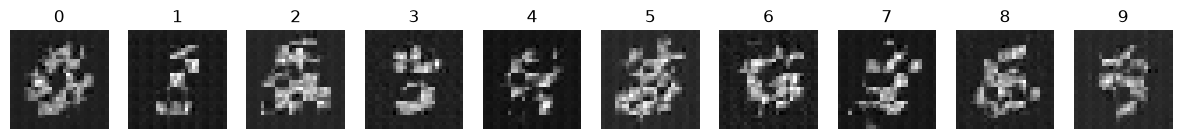

Model: cuda:0
Digits: cuda:0


In [ ]:
match MODE:
    case Mode.CNN:
        model = FlowMatching().to(device)
    case Mode.BasicTransformer:
        model = FlowMatching_with_Transformer().to(device)

initial_state = {
    name: param.detach().clone()
    for name, param in model.named_parameters()
}

loader = create_loader(training_size=10000, batch_size=256)
train(model, loader)

# save_model(model, name_suffix="10_000_basemodel_v2")

# model = load_model(model)
show_all_digits(model)

print("Model:", next(model.parameters()).device)
print("Digits:", torch.arange(10, device=device).device)

visualize_params(model.named_parameters(), initial_state_dict=initial_state)




Epoch 1: loss = 0.4184
Epoch 2: loss = 0.3412
Epoch 3: loss = 0.3337
Epoch 4: loss = 0.3351
Epoch 5: loss = 0.3282
Epoch 6: loss = 0.3248
Epoch 7: loss = 0.3266
Epoch 8: loss = 0.3214
Epoch 9: loss = 0.3212
Epoch 10: loss = 0.3231
Epoch 11: loss = 0.3153
Epoch 12: loss = 0.3125
Epoch 13: loss = 0.3110
Epoch 14: loss = 0.3103
Epoch 15: loss = 0.3073
Epoch 16: loss = 0.3033
Epoch 17: loss = 0.3068
Epoch 18: loss = 0.2983
Epoch 19: loss = 0.3051
Epoch 20: loss = 0.3005
Epoch 21: loss = 0.2965
Epoch 22: loss = 0.2942
Epoch 23: loss = 0.2924
Epoch 24: loss = 0.2921
Epoch 25: loss = 0.2928
Epoch 26: loss = 0.2896
Epoch 27: loss = 0.2943
Epoch 28: loss = 0.2905
Epoch 29: loss = 0.2866
Epoch 30: loss = 0.2833
Epoch 31: loss = 0.2821
Epoch 32: loss = 0.2854
Epoch 33: loss = 0.2837
Epoch 34: loss = 0.2765
Epoch 35: loss = 0.2782
Epoch 36: loss = 0.2726
Epoch 37: loss = 0.2796
Epoch 38: loss = 0.2803
Epoch 39: loss = 0.2744
Epoch 40: loss = 0.2743
Epoch 41: loss = 0.2767
Epoch 42: loss = 0.2785
E

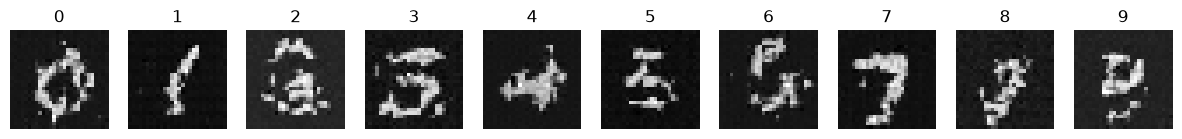

In [ ]:
# train for another 50 epochs
save_model(model, name_suffix="10_000_basemodel_v2")
previous_state = {
    name: param.detach().clone()
    for name, param in model.named_parameters()
}

model.to(device)
train(model, loader, training_epochs=50)
show_all_digits(model)

visualize_params(model.named_parameters(), initial_state_dict=previous_state)

In [43]:
initial_state = {
    name: param.detach().cpu().clone()
    for name, param in model.named_parameters()
}


visualize_params(model.named_parameters(), initial_state_dict=initial_state)

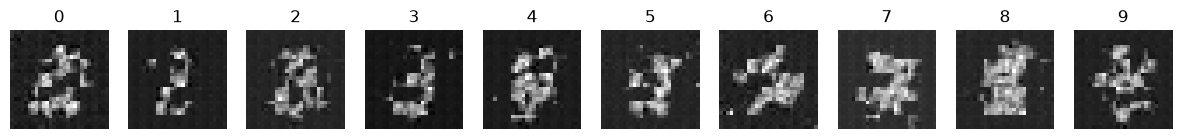

In [6]:
# Generate and visualize samples for all digits with a higher number of denoising steps
model.to(device)
show_all_digits(model, denoising_steps=1000)

# -> does not get better with more denoising steps

In [13]:
"""
Functions for fine-tuning the model on a specific digit and generating samples for that digit.
"""

def fine_tune_digit(model, digit, training_epochs=20):
    # Create a new model instance for fine-tuning
    fine_tuned_model = type(model)().to(device)
    fine_tuned_model.load_state_dict(model.state_dict())

    # Create a DataLoader for the specific digit
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    dataset = datasets.MNIST(
        root="./data", 
        train=True,
        download=True,
        transform=transform,
    )
    indices = [i for i, (_, d) in enumerate(dataset) if d == digit]
    subset = Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=128, shuffle=True)

    # Fine-tune the model on the specific digit
    train(fine_tuned_model, loader, training_epochs=training_epochs)

    return fine_tuned_model


def fine_tune_all_digits(base_model, training_epochs=20):
    fine_tuned_models = {}
    for digit in range(10):
        print(f"Fine-tuning for digit {digit}...")
        fine_tuned_model = fine_tune_digit(base_model, digit, training_epochs)
        save_model(fine_tuned_model, name_suffix=f"digit_{digit}")
        fine_tuned_models[digit] = fine_tuned_model

    # visualize the fine-tuned models for each digit
    for digit, model in fine_tuned_models.items():
        print(f"Visualizing fine-tuned model for digit {digit}...")
        show_all_digits(model)
    return fine_tuned_models

Loading and visualizing fine-tuned model for digit 0...


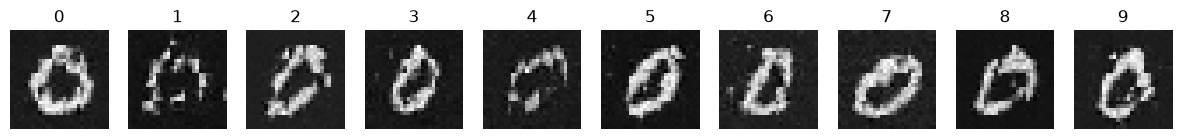

Loading and visualizing fine-tuned model for digit 1...


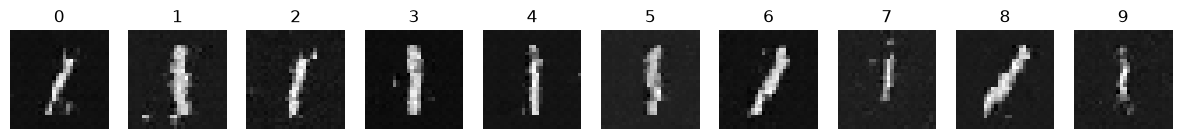

Loading and visualizing fine-tuned model for digit 2...


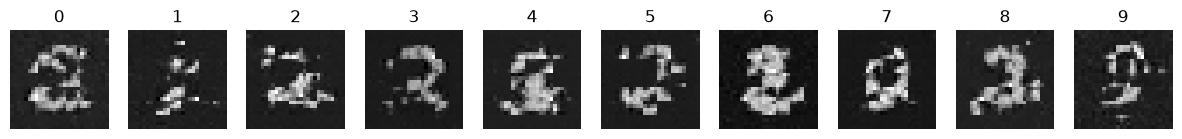

Loading and visualizing fine-tuned model for digit 3...


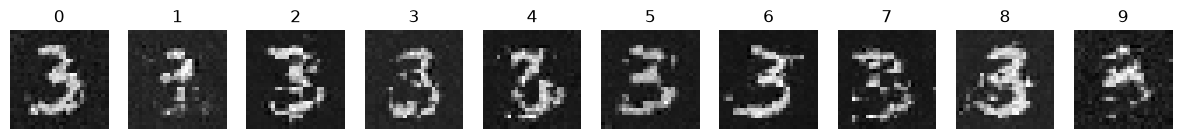

Loading and visualizing fine-tuned model for digit 4...


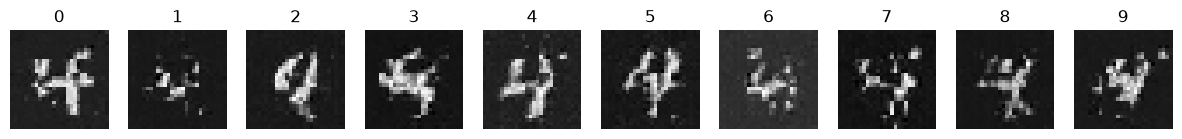

Loading and visualizing fine-tuned model for digit 5...


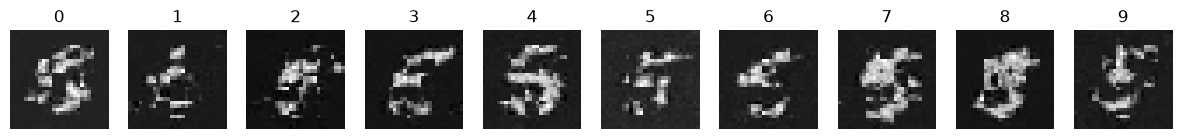

Loading and visualizing fine-tuned model for digit 6...


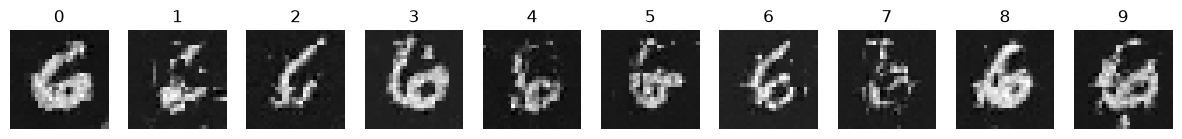

Loading and visualizing fine-tuned model for digit 7...


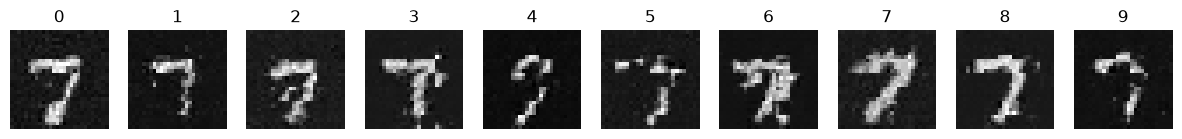

Loading and visualizing fine-tuned model for digit 8...


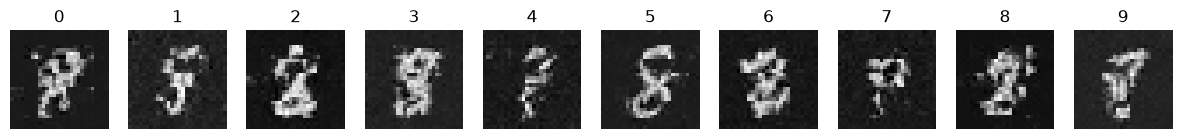

Loading and visualizing fine-tuned model for digit 9...


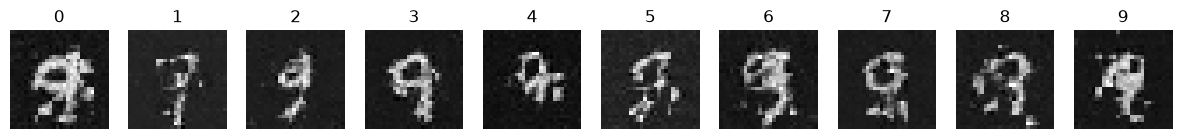

In [18]:
# fine_tune_all_digits(model, training_epochs=20)

for digit in range(10):
    print(f"Loading and visualizing fine-tuned model for digit {digit}...")
    fine_tuned_model = type(model)().to(device)
    fine_tuned_model = load_model(fine_tuned_model, name_suffix=f"digit_{digit}")
    show_all_digits(fine_tuned_model)

In [ ]:
# Visualize parameter statistics for the fine-tuned models in comparison to the base model
base_model = type(model)().to(device)
base_model = load_model(base_model, name_suffix="10_000_basemodel")
initial_state = base_model.state_dict()
for digit in range(10):
    print(f"Visualizing parameters for fine-tuned model of digit {digit}...")
    fine_tuned_model = type(model)().to(device)
    fine_tuned_model = load_model(fine_tuned_model, name_suffix=f"digit_{digit}")
    visualize_params(fine_tuned_model.named_parameters(), initial_state_dict=initial_state)

Visualizing parameters for fine-tuned model of digit 0...


RuntimeError: Error(s) in loading state_dict for FlowMatching_with_Transformer:
	Missing key(s) in state_dict: "layers.6.self_attn.in_proj_weight", "layers.6.self_attn.in_proj_bias", "layers.6.self_attn.out_proj.weight", "layers.6.self_attn.out_proj.bias", "layers.6.linear1.weight", "layers.6.linear1.bias", "layers.6.linear2.weight", "layers.6.linear2.bias", "layers.6.norm1.weight", "layers.6.norm1.bias", "layers.6.norm2.weight", "layers.6.norm2.bias", "layers.7.self_attn.in_proj_weight", "layers.7.self_attn.in_proj_bias", "layers.7.self_attn.out_proj.weight", "layers.7.self_attn.out_proj.bias", "layers.7.linear1.weight", "layers.7.linear1.bias", "layers.7.linear2.weight", "layers.7.linear2.bias", "layers.7.norm1.weight", "layers.7.norm1.bias", "layers.7.norm2.weight", "layers.7.norm2.bias", "output_proj.0.weight", "output_proj.0.bias", "output_proj.2.weight", "output_proj.2.bias". 
	Unexpected key(s) in state_dict: "output_proj.weight", "output_proj.bias". 

In [31]:
model.layers[0].linear1.bias 

Parameter containing:
tensor([-0.0773, -0.1220, -0.0322, -0.0560, -0.0838,  0.0274,  0.0291, -0.0164,
        -0.0949, -0.0290, -0.0251, -0.1453,  0.0181, -0.0950, -0.1284, -0.1239,
         0.0282, -0.0436, -0.0235, -0.0776, -0.0143, -0.1565, -0.0510, -0.0181,
         0.0629,  0.0590, -0.0973, -0.0408,  0.0192,  0.0937,  0.0948, -0.1508,
        -0.0171,  0.0065, -0.0060,  0.0121, -0.1042, -0.0264, -0.1240,  0.0792,
        -0.0468, -0.1190, -0.1441,  0.0352,  0.0484,  0.0014, -0.1178,  0.0440,
        -0.0369, -0.0702,  0.0129, -0.0234, -0.1253, -0.0152,  0.0522, -0.0512,
         0.0210,  0.0844, -0.1040,  0.0731, -0.1248, -0.0772,  0.0754, -0.0066,
        -0.1725, -0.0262, -0.0691, -0.0215, -0.0498, -0.0170,  0.0661, -0.2019,
        -0.0670, -0.0380,  0.0220,  0.0738, -0.1262, -0.0080, -0.0719, -0.1085,
         0.0075, -0.0141,  0.0565, -0.0634, -0.0523,  0.0575,  0.0225, -0.0394,
        -0.0561, -0.0842, -0.1039,  0.0285, -0.0263,  0.0045, -0.0655, -0.0414,
        -0.1522, -

In [33]:
layer_params = {}
pattern = re.compile(
    r"^layers\.(\d+)\.(.+)$"
)
state_dict = model.named_parameters()

for name, tensor in state_dict:

        match = pattern.match(name)

        if match is None:
            continue

        layer_idx = int(match.group(1))
        param_name = match.group(2)

        # Only parameters, not buffers
        if not torch.is_tensor(tensor):
            continue

        layer_params.setdefault(layer_idx, {})
        layer_params[layer_idx][param_name] = tensor.detach().cpu().float()

        print(f"Layer {layer_idx}, Parameter: {param_name}, Shape: {tensor.shape}") 
        print(layer_params[layer_idx][param_name])


Layer 0, Parameter: self_attn.in_proj_weight, Shape: torch.Size([192, 64])
tensor([[ 0.0879,  0.2454,  0.1701,  ...,  0.1833, -0.0422,  0.0260],
        [-0.0120, -0.0626,  0.0370,  ..., -0.1647,  0.0919,  0.0246],
        [-0.0198, -0.0225, -0.0409,  ..., -0.0787, -0.0668,  0.1619],
        ...,
        [-0.0418, -0.0290, -0.0713,  ..., -0.0546,  0.1144,  0.0945],
        [-0.0202, -0.1390, -0.0485,  ..., -0.0425, -0.1255,  0.0363],
        [ 0.0104,  0.0452, -0.1141,  ...,  0.0275, -0.1032,  0.0998]])
Layer 0, Parameter: self_attn.in_proj_bias, Shape: torch.Size([192])
tensor([-2.7900e-03,  3.9658e-02,  1.7623e-02, -4.2991e-03, -2.1258e-02,
        -3.3071e-02, -1.9562e-02,  6.4721e-02,  1.6775e-02, -8.0328e-03,
        -2.6525e-02, -6.7322e-02,  9.0401e-04, -2.9785e-02,  4.3116e-02,
         8.9150e-03,  4.6172e-02, -6.6526e-02,  2.7124e-02, -9.8322e-02,
         9.7606e-02,  1.7548e-02,  1.7176e-01, -3.8975e-02,  1.1438e-01,
        -9.1554e-02,  9.7667e-02, -1.4277e-01,  9.8229e-0